# Exercise 6 - Monte Carlo Localization 
### GuG and GE: [10.0] - Questions 6.1 to 6.4 
### MoRo: [16.0] - Questions 6.1 to 6.5
---

In [22]:
from ex6 import *

#Autoloads evertyhing flaged with %aimport
%load_ext autoreload    
%autoreload 1               
%aimport ex6  

#Matplotlib output to cell
%matplotlib inline   

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
In this assignment, you need to implement a **particle filter** algorithm for localizing a robot in a given map.
The dataset comes from a differential-drive robot equipped with a 2D laser scanner.

Compared to the previous assignment, where you implemented an **EKF** for localization, using a laser scanner produces a large number of observations, which would lead to a very large state covariance matrix in the EKF. This makes the EKF computationally expensive and less suitable for this type of sensor data.

For this reason, it is common to use a **particle filter** for robot localization when working with 2D laser scanners. Particle filters handle many observations efficiently and can better deal with nonlinearities and multimodal uncertainty.

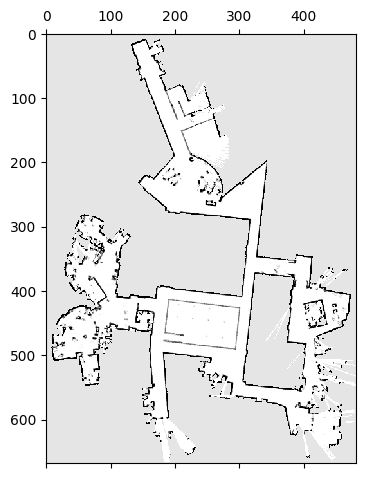

In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

data = pickle.load(open("dataset_mit_csail.p", "rb"))

plt.matshow(data['img_map'], cmap="gray")
plt.show()

The following data is provided in `data`:

- *img_map* is the image of the environment where the robot must localize
- *likelihood_map* is the likelihood map defined over the environment and used for computing the weights of the particles
- *odom* is the noisy odometry motion parameters observed by the robot during navigation in the form: $\delta_{rot1}, \delta_{trans}, \delta_{rot2}$
- *gt_odom* is the ground truth odometry motion parameters
- *z* are the laser range measurements (37 beams $\rho_i, \phi_i$) obtained by the robot during navigation, where $\rho_i$ is the range and $\theta_i$ the corresponding firing angle defined wrt the robot orientation

You can access the `data` as follows:

Odom at step 25 is:  [ 0.11378333  0.50803543 -0.18586595]
True odom at step 25 is:  [ 0.08237367  0.53204367 -0.23049267]
Angles at step 10 is:  [-1.570796e+00 -1.483526e+00 -1.396256e+00 -1.308986e+00 -1.221716e+00
 -1.134446e+00 -1.047176e+00 -9.599060e-01 -8.726360e-01 -7.853660e-01
 -6.980960e-01 -6.108260e-01 -5.235560e-01 -4.362860e-01 -3.490160e-01
 -2.617460e-01 -1.744760e-01 -8.720600e-02  6.400000e-05  8.733400e-02
  1.746040e-01  2.618740e-01  3.491440e-01  4.364140e-01  5.236840e-01
  6.109540e-01  6.982240e-01  7.854940e-01  8.727640e-01  9.600340e-01
  1.047304e+00  1.134574e+00  1.221844e+00  1.309114e+00  1.396384e+00
  1.483654e+00  1.570924e+00]
Ranges at step 10 is:  [ 3.    2.99  1.33  1.23  1.16  1.14  1.34  1.43  1.4   2.94  3.    3.07
  3.2   3.22  3.59  3.7   3.86  2.75 81.91  1.65  1.68  1.81 81.91 81.91
  4.73  4.76  3.76  4.18  2.3   2.31  5.7   2.33  2.41  4.23  4.09  4.02
 81.91]


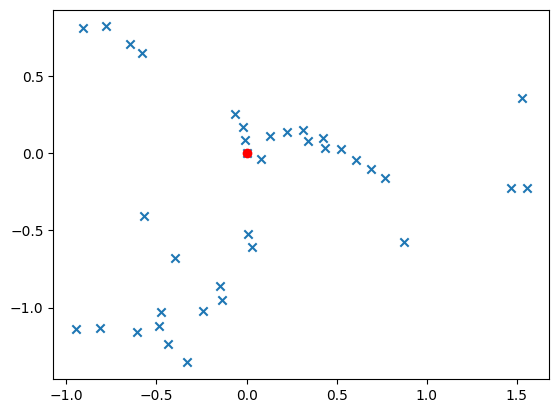

In [24]:
# get odometry reading at timestep 25
odom_25 = data['odom'][25]
print("Odom at step 25 is: ", odom_25)

# get ground truth odometry reading at timestep 25
odom_gt_25 = data['gt_odom'][25]
print("True odom at step 25 is: ", odom_gt_25)

# get observed scan at timestep 10
z_10 = data['z'][10]
print("Angles at step 10 is: ", z_10[0,:])
print("Ranges at step 10 is: ", z_10[1,:])
plot_observation(z_10)

In the previous plot you see the sensor readings at timestep 10. Even though the robot has access to the map of the environment, determining its exact position from a single observation is still challenging. This is due to:
- Sensor noise — measurements are imprecise.
- Ambiguous observations — the same sensor reading may match multiple places on the map.

---
## 6.1 Motion update [1.0]

The `sample_motion_model_odometry` function defines the sampling-based odometry motion model. 

This function takes as input:

- the initial pose of the robot $x_{t-1} = [x,y,\theta]$
- the motion parameters ${m_t} = [\delta_{rot1}, \delta_{trans}, \delta_{rot2}]$ 
- the noise parameters $\mathbf{\alpha} = [0.1, 0.1, 0.1, 0.1]$

The output is a new (sampled) pose predicted by the motion model.

Implement the `sample_motion_model_odometry` function.

**Hint** You **can** adapt your implementation from Exercise 3 to direclty process motion parameters $u_t$!

In [25]:
noise = [0.1, 0.1, 0.1, 0.1]
odom = [0.0, 0.1, 1.0]
robo = [0.0, 0.0, np.pi/2]

sample_motion_model_odometry(robo, odom, noise)


array([-0.06111919,  0.32708109,  2.36058697])

---
## 6.2 Compute weights [3.0]

The `compute_weights` function is responsible for computing the importance weight for each particle $p$ according to the observation model.
The observation model assumes the K beams $b$ to be conditionally independent:

$$w_{p} = \prod_{b=1}^{K} w_{p,b} $$

The weights for each laser beams are defined as:
$$
w_{p,b} =
\begin{cases} 
1 & \text{if range $>$ max\_range} \\
p(z_{b} \mid x_{p},m) & \text{if within map} \\
p_{outside} & \text{if outside map} 
\end{cases}
$$


Implement the `compute_weights` function.


**Hint:** For the hypothesis of pose 2, all beams lie outside the grid map. For pose 1, it is roughly 50%!

In [26]:
z_obs = data['z'][350]
map_res = 0.1
gridmap = 255 - data['img_map']
likelihood_map = data['likelihood_map']

p_outside = 0.1
max_range = 10

pose1 = [0.0, 0.0, 0.0]
pose2 = [40.0, 200.0, 0.0]

for pose in [pose1,pose2]:
    particle_weight = compute_weights(pose, z_obs, gridmap, likelihood_map, map_res,p_outside, max_range)
    print(f'The weight of that particular particle at {pose} is {particle_weight}')

The weight of that particular particle at [0.0, 0.0, 0.0] is 7.565150589373635e-19
The weight of that particular particle at [40.0, 200.0, 0.0] is 1.0000000000000019e-35


---
## 6.3 Resampling [3.0]

The `low_variance_resampler` function is responsible for re-sampling particles according to their weight (the higher the more likely to be samples) and, thus, “kills” the particles with low weight.

Implement the `low_variance_resampler` function (low-variance resampling).

**Hint:** The dotted lines should never cross particle IDs with a different color! Make sure the resample offset is passed correclty.

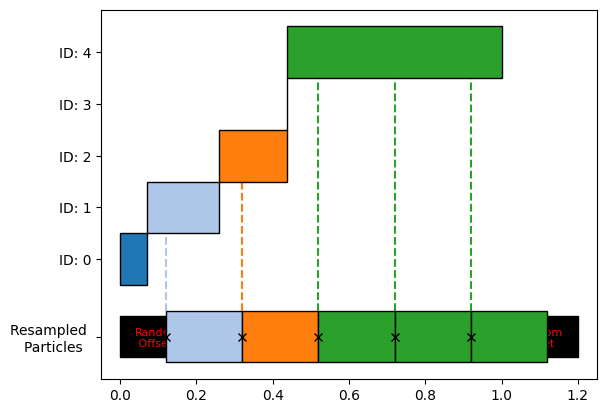

In [27]:
num_particles = 5
map_res = 0.1
particles = init_uniform(num_particles, data['img_map'], map_res)
z_obs = data['z'][60]
gridmap = 255 - data['img_map']
likelihood_map = data['likelihood_map']
weights = np.zeros(num_particles)

# running loop for each particle
for m in range(num_particles):
    # weight computation
    weights[m] = compute_weights(particles[m,:], z_obs, gridmap, likelihood_map, map_res)

#Normalize
weights = weights/np.sum(weights)

# low variance resampling
resampled_particles, resampled_idx, resample_offset = low_variance_resampler(particles, weights)
plot_low_variance_resampler(weights, num_particles, resampled_idx, resample_offset)


---
## 6.4 Localization [3.0]

Once you complete all the above functions, implement the main procedure of Monte Carlo localization `mc_localization` which recursively estimate the position of the robot using the odometry data and the laser scans.

The map reex6 is 0.1 and each particle is a $(x,y,\theta)$ pose.

Plot the belief about the position of the robot after the sequence of odometry readings and laser scans provided in `data` by using the `plot_particles` function.

**Hint:** You can lower the number of particles and timesteps for debugging purpose!


Saved GIF: MCL_p=5000.gif
      IMG: FINAL_STATE_MCL_p=5000.png


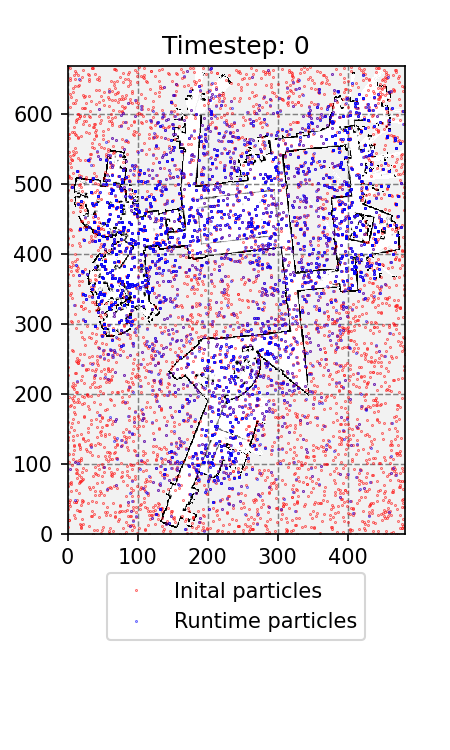

In [28]:
num_particles = 5000
num_timesteps = 50

map_res = 0.1

particles = init_uniform(num_particles, data['img_map'], map_res)
gridmap = 255 - data['img_map']
likelihood_map = data['likelihood_map']
odom = data['odom']
z = data['z']
img_map = data['img_map']

# executing mcl over the sequence of odometry readings
mc_localization(odom[:num_timesteps], z[:num_timesteps], num_particles, particles, noise, gridmap, likelihood_map, map_res, img_map,viz_timestep_intervall=1)

---
---

### **Attention** Question 6.5 is required only for MoRo students. GE and GuG students are not required to answer Question 6.5, but are welcome to do so if they wish.

---
---
## 6.5 Parallelization [6.0] - MoRo ONLY
Increasing the number of particles is extremely inefficient due to the repeated looping over each particle. Your task is to implement an optimized version of the algorithm.

The improved implementation should leverage parallelized, vectorized computations to reduce runtime. While the focus is on optimizing performance with respect to the number of particles, note that parallelization across the time domain is not possible, since we are simulating a robot rather than working with real-time data.

To do this, you have to adapt the following functions from the non-parallelized versions:

- **Remove looping** over particles in `mc_localization`:
    - `compute_weights_parallel`:
    - `sample_motion_model_odometry_parallel`:

- **Remove looping** over bins:
    - `low_variance_resampler_parallel`:

- Implement the corresping helper functions to **accept ararys** instead of single particles:
    - `world2map_parallel`:
    - `ranges2cells_parallel`:
    - `ranges2points_parallel`:
    - `v2t_parallel`:
    - `get_sample_parallel`: Added input variable count to define number of samples to draw 



**Hint:** The parallelized should give you similar results - Be careful, this might not apply for small number of particles and short time horizons!


Saved GIF: VectorizedMCL_p=5000.gif
      IMG: FINAL_STATE_VectorizedMCL_p=5000.png


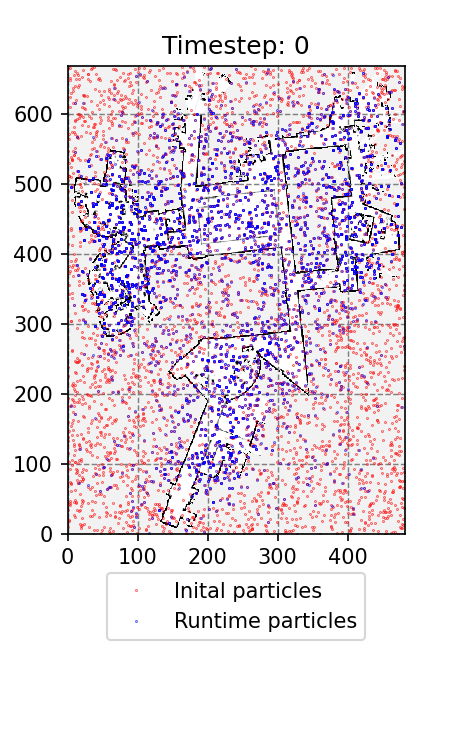

In [29]:
num_particles = 5000
num_timesteps = 50

parallel_mode = True

mc_localization(odom[:num_timesteps], z[:num_timesteps], num_particles, particles, noise, gridmap, likelihood_map, map_res, img_map,viz_timestep_intervall=1, parallel_mode=parallel_mode)

You can further increase the number of particles - but the trend should be consistent !

In [30]:
particles = 50
total_scale_steps = 8

plot_parallelization_comparison(particles,total_scale_steps)

FileNotFoundError: [Errno 2] No such file or directory: '/home/lobmaier/TEACHING/exercises-sse/2025/ex06-monte-carlo-localization/solution/dataset_mit_csail.p'